In [1]:
# from metocean_stats.stats.aux_funcs import *
# from metocean_stats import plots
import pandas as pd
import xarray as xr

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as mticker

In [7]:
target_spectra_Vartdalsfjorden = xr.open_dataset(r'data/Target_spec_Vartdalsfjorden_None.nc')


pred_specwind_CNN_Vartdalsfjorden = xr.open_dataset(r'data/run_model_CNN_specwind_Vartdalsfjorden_(2017-01-01 to 2023-02-28)_test')
pred_spec_CNN_Vartdalsfjorden = xr.open_dataset(r'data/run_model_CNN_spec_Vartdalsfjorden_(2017-01-01 to 2023-02-28)_test')
pred_wind_CNN_Vartdalsfjorden = xr.open_dataset(r'data/run_model_CNN_wind_Vartdalsfjorden_(2017-01-01 to 2023-02-28)_test')
pred_int_CNN_Vartdalsfjorden = xr.open_dataset(r'data/run_model_CNN_int_params_Vartdalsfjorden_(2017-01-01 to 2023-02-28)_test')

pred_specwind_MLP_Vartdalsfjorden = xr.open_dataset(r'data/run_model_MLP_specwind_Vartdalsfjorden_(2017-01-01 to 2023-02-28)_test')
pred_spec_MLP_Vartdalsfjorden = xr.open_dataset(r'data/run_model_MLP_spec_Vartdalsfjorden_(2017-01-01 to 2023-02-28)_test')
pred_wind_MLP_Vartdalsfjorden = xr.open_dataset(r'data/run_model_MLP_wind_Vartdalsfjorden_(2017-01-01 to 2023-02-28)_test')
pred_int_MLP_Vartdalsfjorden = xr.open_dataset(r'data/run_model_MLP_int_params_Vartdalsfjorden_(2017-01-01 to 2023-02-28)_test')

In [8]:
def compute_mean_wave_direction(data, var='SPEC', mean_pdir=False):
    '''
    Compute the mean wave direction from a directional wave energy spectrum.

    This function calculates the mean wave direction dir_mean based on the 
    discrete approximation of the integrals:

        a = ∫∫ cos(dir) * F(freq, dir) dfreq ddir
        b = ∫∫ sin(dir) * F(freq, dir) dfreq ddir
        dir_mean = arctan2(b, a)

    where:
        - F(freq, dir) is the spectral energy density as a function of frequency and direction.
        - The integrals are approximated by summations over the frequency and
          direction bins weighted by the bin widths.

    If mean_pdir=True, the mean peak direction is calculated instead. 
          
    Parameters:
    - data : xarray.Dataset or xarray.DataArray
        Wave spectrum with dimensions including 'freq' and 'direction'. If a Dataset,
        the spectral variable is specified by `var`.
    - var : str, optional, default = 'SPEC'
        Name of the spectral variable in `data` if `data` is a Dataset.
    - mean_pdir : bool, optional, default = False,
        False : calculates mean wave direction
        True : calculated mean peak wave direction

    Returns:
    - mean_dir_rad : xarray.DataArray
        Mean (peak) wave direction in radians using the mathematical convention:
        0 = East, positive counter-clockwise (CCW).

    Notes:
    - Frequency and direction bin widths are computed using gradients and used to weight the integration.
    - The final direction is based on vector summation (a, b) and converted using arctangent.
    - Based on the method in the WAVEWATCH III User Manual (v6.07, NOAA/NCEP, 2019).
    '''

    try:
        spectrum = data[var].sortby('direction')
    except KeyError :
        spectrum = data.sortby('direction')

    direction = data['pdir'] if mean_pdir else spectrum['direction']

    # directions_rad = np.deg2rad((450 - direction) % 360)                                                        # Convert to mathematical convention (radians, pointing to East counterclockwise)
    directions_rad = np.deg2rad(direction)
    if not mean_pdir:
        # Full 2D integration
        delta_freq = np.gradient(spectrum.frequency.values)                                                          # Calculate frequency and dir bin widths
        delta_dir = np.gradient(spectrum['direction'])
        delta_dir_rad = np.deg2rad(delta_dir)                   
        dfreq_2d = xr.DataArray(delta_freq, dims=['frequency'])                                                      # Create DataArrays for bin widths to broadcast over spectrum dims
        ddir_2d = xr.DataArray(delta_dir_rad, dims=['direction'])
        area_element = dfreq_2d.broadcast_like(spectrum) * ddir_2d.broadcast_like(spectrum)                     # Compute the area element dfreq ddir for each frequency-direction bin by outer product


    if mean_pdir:
        peak_directions_rad = np.deg2rad(450 - (spectrum.integrate('frequency').idxmax(dim='direction')) % 360)      # Computes mean peak direction
        a = xr.ufuncs.cos(peak_directions_rad) 
        b = xr.ufuncs.sin(peak_directions_rad)

    else:
        a = (xr.ufuncs.cos(directions_rad) * spectrum * area_element).sum(dim=['frequency', 'direction'])            # Compute weighted sums a and b over freq and direction dimensions
        b = (xr.ufuncs.sin(directions_rad) * spectrum * area_element).sum(dim=['frequency', 'direction'])

    mean_dir_rad = np.arctan2(b, a)

    return mean_dir_rad

In [9]:
import scipy
from scipy.integrate import simpson
def integrated_parameters_dict(
    spec:       np.ndarray|xr.DataArray, 
    frequencies:np.ndarray|xr.DataArray, 
    directions: np.ndarray|xr.DataArray,
    params: list = ['Hs', 'peak_freq', 'peak_dir']) -> dict:
    """
    Calculate the integrated parameters of a 2D wave spectrum, 
    or some array/list of spectra. Uses simpsons integration rule.

    Implemented: Hs, peak dir, peak freq.

    a = ∫∫ cos(dir) * F(freq, dir) dfreq ddir
    b = ∫∫ sin(dir) * F(freq, dir) dfreq ddir
    
    Arguments
    ---------
    spec : np.ndarray or xr.DataArray
        An array of spectra. The shape must be either 
        [..., frequencies, directions] or [..., frequencies*directions].
    frequencies : np.ndarray or xr.DataArray
        Array of spectra frequencies.
    directions: np.ndarray or xr.DataArray
        Array of spectra directions.
        
    Returns
    -------
    spec_parameters : dict[str, np.ndarray]
        A dict with keys Hs, peak_freq, peak_dir, and values are arrays
        of the integrated parameter.
    """
    # spec = spec_dataset['SPEC']

    spec_parameters = {}

    # Make sure all arrays are numpy.
    if isinstance(spec, xr.DataArray):
        spec = spec.data
    if isinstance(frequencies, xr.DataArray):
        frequencies = frequencies.data
    if isinstance(directions, xr.DataArray):
        directions = directions.data

    params_list = {'Hs', 'peak_freq', 'peak_period', 'peak_dir', 'mean_freq', 'mean_period', 'mean_dir'}
    if invalid:=set(params)-params_list: 
        raise ValueError(f'Invalid parameters: {invalid}. This function only calculates: {params_list}')

    # Check if spec values and shape are OK
    if np.any(spec < 0):
        print("Warning: negative spectra values set to 0")
        spec = np.clip(spec, a_min=0, a_max=None)

    flat_check = (len(spec.shape)<2)
    freq_check = (len(frequencies) != spec.shape[-2])
    dir_check = (len(directions) != spec.shape[-1])
    if flat_check or freq_check or dir_check:
        try:
            spec = spec.reshape(spec.shape[:-1]+(len(frequencies),len(directions)))
        except Exception:
            raise IndexError("Spec shape does not match frequencies and directions.")

    if 'peak_freq' in params or 'peak_dir' in params:
        # Use argmax to find indices of largest value of each spectrum.
        peak_dir_freq = np.array([np.unravel_index(s.argmax(),s.shape) 
            for s in spec.reshape(-1,len(frequencies),len(directions))])
        peak_dir_freq = peak_dir_freq.reshape(spec.shape[:-2]+(2,))
        peak_freq = frequencies[peak_dir_freq[...,0]]
        peak_dir = directions[peak_dir_freq[...,1]] if 'peak_dir'in params else None
        spec_parameters['peak_freq'] = peak_freq
        spec_parameters['peak_dir'] = peak_dir
        spec_parameters['peak_dir_rad'] = np.deg2rad(peak_dir)

    
    if 'Hs' in params or 'mean_dir' in params or 'mean_freq' in params or 'mean_period' in params:
        # Integration requires radians
        if np.max(directions) > 2*np.pi: 
            directions = np.deg2rad(directions)
        
        # Sort on direction before integration
        sorted_indices = np.argsort(directions)
        directions = directions[sorted_indices]
        spec = spec[...,sorted_indices]
        
        # Integration with simpson's rule
        S_f = simpson(spec, x=directions)
        m0 = simpson(S_f, x=frequencies)
        Hs = 4 * np.sqrt(m0)

        spec_parameters['Hs'] = Hs

        if 'mean_freq' in params or 'mean_period' in params:
            m1 = simpson(frequencies*S_f, x=frequencies)
            mean_freq = (m1/m0)
            spec_parameters['mean_freq'] = mean_freq
            if 'mean_period' in params:  
                mean_period = (m0/m1)
                spec_parameters['mean_period'] = mean_period
    
    if 'mean_dir' in params:
        spec_dataset = xr.DataArray(
            spec,
            dims=["time", "frequency", "direction"],
            coords={
                "time" : np.arange(spec.shape[0]),
                "frequency": frequencies,
                "direction": directions,
            },
            name="SPEC")
        
        mean_dir = np.rad2deg(compute_mean_wave_direction(spec_dataset))
        spec_parameters['mean_dir'] = mean_dir

    return spec_parameters

In [10]:
from functools import reduce
def Dataset_to_DF(dataset, prefix, pred_spec):
    if isinstance(dataset, dict):
        df = pd.DataFrame(dataset).add_prefix(prefix)
        df = df.set_index(pred_spec['time'].to_pandas())
    else:
        df = dataset.to_dataframe().add_prefix(prefix)
    df.index.name = None
    return df

def make_dfs(specs, target, loc, params):

    dfs = []
    i=0
    for var_name, spec in specs.items():
        # print(spec.sel(loc=loc)['SPEC'])
        # int_params = spec_funcs.integrated_parameters_dict(spec.sel(loc=loc)['SPEC'], spec.sel(loc=loc)['freq'], spec.sel(loc=loc)['direction'])
        # print(params)
        # if i>2:
        #     int_params = {
        #             "Hs": spec["Hs"].isel(location=loc),
        #             "peak_freq": spec["peak_freq"].isel(location=loc),
        #             "peak_dir": spec["peak_dir"].isel(location=loc),
        #     }
        # else:
        if (spec.time.values != list(specs.values())[0].time.values).all():
            raise ValueError(f'The spec datasets do not share the same timestamps. \n{var_name} have time: {spec.time.values} \n{list(specs.keys())[0]} have time: {list(specs.values())[0].time.values}')
        # int_params = integrated_parameters_dict(spec.sel(loc=loc)['SPEC'], spec.sel(loc=loc)['frequency'], spec.sel(loc=loc)['direction'], params=params)
        int_params = integrated_parameters_dict(spec.sel(loc=loc)['SPEC'], spec.sel(loc=loc)['frequency'], spec.sel(loc=loc)['direction'], params=params)
        # print(int_params['peak_dir_rad'])
        # int_params = integrated_parameters_dict(spec['SPEC'], spec['frequency'], spec['direction'], params=params)
        df = Dataset_to_DF(int_params, var_name, target.sel(loc=loc))
        dfs.append(df)
        i+=1

    df = reduce(
        lambda df1, df2: pd.merge(df1, df2, left_index=True, right_index=True),
        dfs
    )

    return df

In [11]:
spec_datasets_Vartdalsfjorden = {'Target ' : target_spectra_Vartdalsfjorden, 
                 'MLP SPEC ' : pred_spec_MLP_Vartdalsfjorden,
                 'CNN SPEC ': pred_spec_CNN_Vartdalsfjorden,
                 'MLP SPECWIND ' : pred_specwind_MLP_Vartdalsfjorden, 
                 'CNN SPECWIND ': pred_specwind_CNN_Vartdalsfjorden,
                 'MLP WIND ' : pred_wind_MLP_Vartdalsfjorden,
                 'CNN WIND ' : pred_wind_CNN_Vartdalsfjorden,              
                 }

names_Vartdalsfjorden = list(spec_datasets_Vartdalsfjorden.keys())


params = ['Hs', 'peak_freq', 'peak_dir', 'mean_freq', 'mean_dir']
df_combined_Vartdalsfjorden_spec = make_dfs(spec_datasets_Vartdalsfjorden, target_spectra_Vartdalsfjorden, 1, params)

for name in df_combined_Vartdalsfjorden_spec.columns:
    if 'mean_dir' in name:
        df_combined_Vartdalsfjorden_spec[name] = np.rad2deg(df_combined_Vartdalsfjorden_spec[name]) 

df_combined_Vartdalsfjorden_spec

,Target peak_freq,Target peak_dir,Target peak_dir_rad,Target Hs,Target mean_freq,Target mean_dir,MLP SPEC peak_freq,MLP SPEC peak_dir,MLP SPEC peak_dir_rad,MLP SPEC Hs,...,MLP WIND peak_dir_rad,MLP WIND Hs,MLP WIND mean_freq,MLP WIND mean_dir,CNN WIND peak_freq,CNN WIND peak_dir,CNN WIND peak_dir_rad,CNN WIND Hs,CNN WIND mean_freq,CNN WIND mean_dir
2022-07-19 00:00:00,0.801802,40.0,0.698132,0.071885,1.020067,59.181080,0.801802,30.0,0.523599,0.065988,...,0.523599,0.072001,1.022899,72.669174,0.801802,30.0,0.523599,0.072103,1.026808,72.131508
2022-07-19 01:00:00,0.801802,40.0,0.698132,0.071880,1.024367,58.467373,0.801802,30.0,0.523599,0.067867,...,0.523599,0.070413,1.029327,71.242157,0.801802,30.0,0.523599,0.070714,1.031494,70.114388
2022-07-19 02:00:00,0.801802,40.0,0.698132,0.075511,0.996923,57.303295,0.801802,30.0,0.523599,0.063858,...,0.523599,0.067613,1.042804,69.438492,0.801802,30.0,0.523599,0.067558,1.041871,67.482147
2022-07-19 03:00:00,0.801802,40.0,0.698132,0.075948,0.995731,56.806370,0.801802,30.0,0.523599,0.060102,...,0.523599,0.061629,1.049330,63.171837,0.801802,30.0,0.523599,0.064068,1.042905,63.415051
2022-07-19 04:00:00,0.728911,30.0,0.523599,0.082946,1.059859,110.363152,0.801802,30.0,0.523599,0.054096,...,0.523599,0.061231,1.071531,84.824776,0.801802,30.0,0.523599,0.059196,1.069728,79.748825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-28 19:00:00,0.881983,250.0,4.363323,0.062781,1.098528,248.981888,0.881983,30.0,0.523599,0.053055,...,0.523599,0.056815,1.078722,133.165710,0.801802,30.0,0.523599,0.054081,1.091276,141.120499
2023-02-28 20:00:00,0.881983,250.0,4.363323,0.064947,1.082638,247.366318,0.728911,230.0,4.014257,0.054472,...,0.523599,0.060053,1.062030,105.629242,0.801802,30.0,0.523599,0.060747,1.068649,96.232193
2023-02-28 21:00:00,0.801802,240.0,4.188790,0.063850,1.083418,252.237564,0.881983,30.0,0.523599,0.054721,...,0.523599,0.065163,1.064317,81.653389,0.801802,30.0,0.523599,0.065579,1.061807,78.176361
2023-02-28 22:00:00,0.881983,250.0,4.363323,0.062584,1.107554,240.721481,0.801802,30.0,0.523599,0.055200,...,0.523599,0.070231,1.035179,80.683571,0.801802,30.0,0.523599,0.071122,1.033754,80.061340


In [23]:
df_int_params_Vartdalsfjorden_CNN = pred_int_CNN_Vartdalsfjorden.to_dataframe().droplevel(
                                                                                'location').add_prefix(
                                                                                'CNN INT ')


df_int_params_Vartdalsfjorden_CNN = df_int_params_Vartdalsfjorden_CNN.rename(columns={'CNN INT peak_dir': 'CNN INT peak_dir_rad'})
df_int_params_Vartdalsfjorden_CNN['CNN INT peak_dir'] = np.rad2deg(df_int_params_Vartdalsfjorden_CNN['CNN INT peak_dir_rad'])

df_int_params_Vartdalsfjorden_MLP = pred_int_MLP_Vartdalsfjorden.to_dataframe().droplevel(
                                                                                'location').add_prefix(
                                                                                'MLP INT ')


df_int_params_Vartdalsfjorden_MLP = df_int_params_Vartdalsfjorden_MLP.rename(columns={'MLP INT peak_dir': 'MLP INT peak_dir_rad'})
df_int_params_Vartdalsfjorden_MLP['MLP INT peak_dir'] = np.rad2deg(df_int_params_Vartdalsfjorden_MLP['MLP INT peak_dir_rad'])

df_int_params_Vartdalsfjorden_MLP

,MLP INT Hs,MLP INT peak_freq,MLP INT peak_dir_rad,MLP INT peak_dir
time,,,,
2022-07-19 00:00:00,0.082967,0.728911,0.523599,30.0
2022-07-19 01:00:00,0.083518,0.728911,0.523599,30.0
2022-07-19 02:00:00,0.084088,0.728911,0.523599,30.0
2022-07-19 03:00:00,0.084174,0.728911,0.523599,30.0
2022-07-19 04:00:00,0.084013,0.728911,0.523599,30.0
...,...,...,...,...
2023-02-28 19:00:00,0.076412,0.728911,0.523599,30.0
2023-02-28 20:00:00,0.076834,0.728911,0.523599,30.0
2023-02-28 21:00:00,0.077672,0.728911,0.523599,30.0


In [24]:
def check_time(datasets):

    i=1
    for spec in datasets:

        if (spec.index != datasets[0].index).all():
            raise ValueError(f'The spec datasets do not share the same timestamps. Dataset {i} have time: {spec['time'].index}, while target have {datasets[0].index}')
        
        i +=1

    print('Datasets have the same timestamps.')
    


datasets_Vartdalsfjorden = [df_combined_Vartdalsfjorden_spec, df_int_params_Vartdalsfjorden_MLP, df_int_params_Vartdalsfjorden_CNN]


check_time(datasets_Vartdalsfjorden)
names_Vartdalsfjorden.append('CNN INT ')

df_combined_Vartdalsfjorden = pd.concat([df_combined_Vartdalsfjorden_spec, df_int_params_Vartdalsfjorden_MLP, df_int_params_Vartdalsfjorden_CNN], axis=1)

df_combined_Vartdalsfjorden

Datasets have the same timestamps.


,Target peak_freq,Target peak_dir,Target peak_dir_rad,Target Hs,Target mean_freq,Target mean_dir,MLP SPEC peak_freq,MLP SPEC peak_dir,MLP SPEC peak_dir_rad,MLP SPEC Hs,...,CNN WIND mean_freq,CNN WIND mean_dir,MLP INT Hs,MLP INT peak_freq,MLP INT peak_dir_rad,MLP INT peak_dir,CNN INT Hs,CNN INT peak_freq,CNN INT peak_dir_rad,CNN INT peak_dir
2022-07-19 00:00:00,0.801802,40.0,0.698132,0.071885,1.020067,59.181080,0.801802,30.0,0.523599,0.065988,...,1.026808,72.131508,0.082967,0.728911,0.523599,30.0,0.077832,0.728911,0.523599,30.000000
2022-07-19 01:00:00,0.801802,40.0,0.698132,0.071880,1.024367,58.467373,0.801802,30.0,0.523599,0.067867,...,1.031494,70.114388,0.083518,0.728911,0.523599,30.0,0.079313,0.728911,0.698132,39.999996
2022-07-19 02:00:00,0.801802,40.0,0.698132,0.075511,0.996923,57.303295,0.801802,30.0,0.523599,0.063858,...,1.041871,67.482147,0.084088,0.728911,0.523599,30.0,0.080063,0.728911,0.698132,39.999996
2022-07-19 03:00:00,0.801802,40.0,0.698132,0.075948,0.995731,56.806370,0.801802,30.0,0.523599,0.060102,...,1.042905,63.415051,0.084174,0.728911,0.523599,30.0,0.080137,0.728911,0.698132,39.999996
2022-07-19 04:00:00,0.728911,30.0,0.523599,0.082946,1.059859,110.363152,0.801802,30.0,0.523599,0.054096,...,1.069728,79.748825,0.084013,0.728911,0.523599,30.0,0.079588,0.728911,0.698132,39.999996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-28 19:00:00,0.881983,250.0,4.363323,0.062781,1.098528,248.981888,0.881983,30.0,0.523599,0.053055,...,1.091276,141.120499,0.076412,0.728911,0.523599,30.0,0.076659,0.728911,0.523599,30.000000
2023-02-28 20:00:00,0.881983,250.0,4.363323,0.064947,1.082638,247.366318,0.728911,230.0,4.014257,0.054472,...,1.068649,96.232193,0.076834,0.728911,0.523599,30.0,0.077111,0.728911,0.523599,30.000000
2023-02-28 21:00:00,0.801802,240.0,4.188790,0.063850,1.083418,252.237564,0.881983,30.0,0.523599,0.054721,...,1.061807,78.176361,0.077672,0.728911,0.523599,30.0,0.077710,0.728911,0.523599,30.000000
2023-02-28 22:00:00,0.881983,250.0,4.363323,0.062584,1.107554,240.721481,0.801802,30.0,0.523599,0.055200,...,1.033754,80.061340,0.079123,0.728911,0.523599,30.0,0.078452,0.728911,0.523599,30.000000


### Taylor function

In [ ]:
from matplotlib.lines import Line2D
def taylor_diagram(df,var_ref,var_comp,norm_std=True, colors=[],output_file='Taylor_diagram.png', ax = None, filter=False, fig_size=None, x_anchor=-0.8, y_anchor=-0.4, marker_size=18, facecolor=None, ncols=4):
    """
    Plot a Taylor diagram
    df: dataframe with all timeseries
    var_ref: list of string with the name of the timeseries of reference
    var_comp: list of strings with the names of the timeseries to be compared with the reference
    norm_std: option to define normalized or non-normalized standard deviation

    Option 1: #[[A,3],[B,3],[C,3]]
    var_ref   = ['hs_sulaA','hs_sulaB','hs_sulaC'] 
    var_comp = ['hs_nora3']
    norm_std = True #can only run with this option

    Option 2 : #Originalen [[A,3],[A,4],[A,5]]
    var_ref   = ['hs_sulaA']
    var_comp = ['hs_nora3','hs_nora4','hs_nora5']
    norm_std = True/False #can run with both options

    Option 3 : #[[A,3],[B,4],[C,5]]
    var_ref   = ['hs_sulaA','hs_sulaB','hs_sulaC']
    var_comp = ['hs_nora3','hs_nora4','hs_nora5']
    norm_std = True #can only run with this option

    """

    def run_taylor(var_ref,var_comp,maxx,index,show, ax, filter, x_anchor, y_anchor, facecolor, ncols=4):
        def correlation(var_ref,var_comp,max_std,radius, removed_indices, filter):
            # Calculate the coordinates of the points x and y
            # Correlation coefficient between the reference and the other(s)
            ccf=np.zeros((len(var_comp)+1))
            ccf[0]=np.corrcoef(df[var_ref[0]].to_numpy(),df[var_ref[0]].to_numpy())[0,1] # Should be 1
            for i in range(len(var_comp)):
                ccf[i+1]=np.corrcoef(df[var_ref[0]].to_numpy(),df[var_comp[i]].to_numpy())[0,1]     
            
            if filter:
                print(f'Also removed the corresponding correlation: {ccf[removed_indices]}')
                ccf = np.delete(ccf, removed_indices)

            # Coordinates of the lines for the correlation
            xbc1=np.arange(0.0,max_std+0.015,0.001)
            corr=np.array([0.2,0.4,0.6,0.8,0.9,0.95,0.99])
            ycr=np.zeros((len(corr),len(xbc1)))
            for r in range(len(corr)):
                for a in range(len(xbc1)):
                    ycr[r,a]=np.tan(np.arccos(corr[r]))*xbc1[a]
                    d=np.sqrt(ycr[r,a]**2+xbc1[a]**2)
                    if d>np.max(radius):
                        ycr[r,a]=np.nan
                    del d

            return ccf,xbc1,ycr,corr

        def set_axes_and_std(var_ref,var_comp,maxx, filter):
            std=np.zeros((len(var_comp)+1))
            std[0]=np.std(df[var_ref].to_numpy())
            for i in range(len(var_comp)):
                std[i+1]=np.std(df[var_comp[i]].to_numpy())
            if norm_std is True:
                std=std/std[0]

            if filter:
                removed_indices = np.where(std > 1.5)[0]
                print('removed indices: ', removed_indices, 'as the values are greater tha 1.5: ', std[removed_indices])
                std = std[std <= 1.5]
                print('Plotted std: ', std)
            else:
                removed_indices = []
            
            # Coordinates of the big circles
            min_std=0
            max_std=maxx + 0.5 #to set the max of x-y

            if max_std<=5:
                step=0.5
            elif ((max_std>5) & (max_std<=10)):
                step=1
            elif ((max_std>10) & (max_std<=20)):
                step=3
            else:
                step=5

            radius=np.arange(min_std+step,max_std,step)
            radius=np.concatenate([radius,np.array([max_std])])
            radius1=radius
            xbc=np.arange(0.0,max_std+0.01,0.0001)
            ybc=np.zeros((len(radius),len(xbc)))
            ysc=np.zeros((len(radius),len(xbc)))
            for r in range(len(radius)):
                for a in range(len(xbc)):
                    ybc[r,a]=np.sqrt(radius[r]**2-xbc[a]**2)
                    ysc[r,a]=np.sqrt(radius1[r]**2-(xbc[a]-std[0])**2)
                    d=np.sqrt(ysc[r,a]**2+xbc[a]**2)
                    if d>np.max(radius):
                        ysc[r,a]=np.nan
                    del d

            return std,max_std,radius,xbc,ybc,step, removed_indices

        def plotting(var_ref,var_comp,maxx,index,filter,x_anchor=-0.8, y_anchor=-0.4, marker_size=18, facecolor=None, ncols=4):
            #Plot the data
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            #Get the data
            std,max_std,radius,xbc,ybc,step, removed_indices = set_axes_and_std(var_ref,var_comp,maxx, filter)
            ccf,xbc1,ycr,corr = correlation(var_ref,var_comp,max_std,radius, removed_indices, filter)

            print('std:', std)
            print('correlation ', ccf)
            print('removed indices: ', removed_indices)

            # centered RMSE (matches Taylor diagram)
            rmse_centered = np.zeros(len(var_comp))
    
            for i in sorted(removed_indices, reverse=True):
                var_comp.pop(i-1)
            
            print('var comp: ', var_comp, len(var_comp))

            for i in range(len(var_comp)):
                rmse_centered[i] = np.sqrt(
                    std[0]**2 +
                    std[i+1]**2 -
                    2 * std[0] * std[i+1] * ccf[i+1]
                )

            print("Centered RMSE (Taylor):", rmse_centered) 

            # Coordinates of the correlation labels
            corr1=np.array([0.0,0.2,0.4,0.6,0.8,0.9,0.95,0.99,1.0])
            text=[]
            xt=np.zeros((len(corr1)))
            yt=np.zeros((len(corr1)))
            #angle=np.zeros((len(corr1)))
            angle=np.array([0,-10,-24,-37,-50,-62,-71,-82,-90])
            for i in range(len(corr1)):
                text.append(str(corr1[i]))                                                                                                                                                                               
                xt[i]=corr1[i]*(max_std+0.1)
                yt[i]=np.sin(np.arccos(corr1[i]))*(max_std+0.1)
                #angle[i]=math.acos(corr1[i])*180.0/math.pi
                angle[i]=angle[i]
            #angle=0.0-angle[::-1]

            
            if show:
                for r in range(len(radius)):
                    ax.plot(xbc[:],ybc[r,:],'k',linewidth=2.0)
                for r in range(len(corr)):
                    ax.plot(xbc1[:],ycr[r,:],'k',linewidth=2.0,linestyle='dotted')

            rmsdif=np.sqrt(std**2+std[0]**2-2*std*std[0]*ccf)
            
            # Coordinates
            x=ccf*std
            y=np.sqrt((rmsdif**2)-((std[0]-x)**2))
            xa=np.linspace(0,max_std+1,1000)
            xx,yy=np.meshgrid(xa,xa)
            del xa
            zz=np.sqrt((xx-std[0])**2+yy**2)
            zz1=np.sqrt(xx**2+yy**2)
            zz=np.where(zz1>max_std,np.nan,zz)
            del zz1

            levels_crms=np.arange(step,np.nanmax(zz)-step,step) if step<1 else np.arange(step,np.nanmax(zz),step)
            CS = ax.contour(xx,yy,zz,colors='gray',linewidths=1.0,linestyles='--',levels=levels_crms)
            fmt = mticker.ScalarFormatter()
            fmt.create_dummy_axis()
            list_tup=[(std[0],yv) for yv in levels_crms]
            ax.clabel(CS, CS.levels, fmt=fmt, fontsize=20,inline=True,inline_spacing=-2,manual=list_tup)

            # Plot reference point in black
            ax.plot(std[0],0.0,'o',clip_on=False,color='k', markersize=18)
            ax.text(std[0]+0.03,0.01,'ref',fontsize=20)#, weight='bold',verticalalignment='center')
            # Plot reference circle
            ybc_r=np.sqrt(std[0]**2-xbc**2)
            ax.plot(xbc,ybc_r,'k',linewidth=3.0)

            list_mrk=['o', 's']

            if colors == []:
                list_col = ['red', 'deeppink', 'blue', 'cyan', 'saddlebrown', 'chocolate', 'dimgray', 'gray']
            else:
                list_col = colors

            combinations = [[list_mrk[i % len(list_mrk)], list_col[i % len(list_col)]]
                for i in range(len(var_comp))]
            combinations=combinations[0:index] if index>0 else combinations[0:len(var_comp)]

            if (index==0) or (index==1):
                legends.append(mlines.Line2D([], [], color='k', marker='o', linestyle='None',markersize=marker_size, label=var_ref[0]))
            else:
                legends.append(mlines.Line2D([], [], color='k', marker='o', linestyle='None',markersize=marker_size, label=var_ref[0]))
        
            if index==0:
                index = index+1
            for ri,rj in zip(range(1,len(var_comp)+1),range(index,len(var_comp)+index)): # Actual plotting of the data
                ax.plot(x[ri],y[ri],clip_on=False,marker=combinations[rj-1][0],color=combinations[rj-1][1],markersize=marker_size, alpha=0.7, markerfacecolor='none' if facecolor else combinations[rj-1][1], markeredgecolor=combinations[rj-1][1] if facecolor else None, markeredgewidth=1.5 if facecolor else None)
                legends.append(mlines.Line2D([],[],marker=combinations[rj-1][0],color=combinations[rj-1][1], linestyle='None',markersize=marker_size, label=var_comp[ri-1]))

                

            if show:
                num_lines = len(legends)
                ncol=1 if num_lines < 7 else 2 if num_lines < 13 else 3
                # Size='x-large'
                # plt.legend(prop=dict(size=Size),handles=legends,ncol=1,loc="upper right", fontsize="22",bbox_to_anchor=(1.5, 1.15))
                if ax == None:
                    plt.legend(handles=legends,ncol=1,loc="lower center", fontsize="20",bbox_to_anchor=(1.5, 1.05))
                else:
                    custom_handles = [
                        Line2D([0], [0],
                            marker='o', linestyle='None',
                            markerfacecolor='none',
                            markeredgecolor='grey',
                            markeredgewidth=1.5,
                            markersize=marker_size,
                            label='MLP (no time shift)'),

                        Line2D([0], [0],
                            marker='s', linestyle='None',
                            markerfacecolor='none',
                            markeredgecolor='grey',
                            markeredgewidth=1.5,
                            markersize=marker_size,
                            label='CNN (no time shift)')
                    ]


                    labels = [h.get_label() for h in legends]
                    labels = [lbl.rsplit(' ', 1)[0] for lbl in labels]

                    all_handles = legends # + custom_handles
                    all_labels = labels # + [h.get_label() for h in custom_handles]
                    
                    plt.legend(handles=all_handles, labels=all_labels,ncol=ncols,loc="lower center", fontsize="20",bbox_to_anchor=(x_anchor, y_anchor))
                # plt.legend(handles=legends,ncol=1,loc="lower center", fontsize="20")

            ax.text(max_std*0.8, max_std*0.8, 'Correlation',ha="center", va="center", size=22, rotation=-45.)
            
            for i in range(len(corr1)):
                ax.plot(xt[i],yt[i],clip_on=False,marker='o',color='None',markersize=8,markerfacecolor='None')
                ax.text(xt[i],yt[i],text[i],ha="center", va="center", size=18, rotation=angle[i])
            
            if norm_std:
                ax.set_xlabel('Normalized standard deviation',fontsize=22)
            else:
                ax.set_xlabel('Standard deviation',fontsize=20)
            
            if show:
                if ax == None:
                    plt.xlim(0,max_std+0.02)
                    plt.ylim(0,max_std+0.02)
                    # plt.xlim(0,1.5)
                    # plt.ylim(0,1.5)
                    plt.xticks(fontsize=20)
                    plt.yticks(fontsize=20)
                    #plt.show()
                else:
                    ax.set_xlim(0,max_std+0.02)
                    ax.set_ylim(0,max_std+0.02)
                    # plt.xlim(0,1.5)
                    # plt.ylim(0,1.5)
                    ax.tick_params(labelsize=20)
                    ax.locator_params(axis='x', nbins=8)
                    ax.locator_params(axis='y', nbins=8)
                    ax.set_title(label = var_ref[0].split(maxsplit=1)[1].replace('_', ' ').capitalize() + '.', fontsize = 22, pad=40, fontweight='bold')

            return 

        plotting(var_ref,var_comp,maxx,index, filter, x_anchor, y_anchor, marker_size, facecolor=facecolor, ncols=ncols)
        return
    
    legends = []
    if (len(var_ref)<len(var_comp)) and (len(var_ref)==1): #for option 2
        print('Option 2')
        if ax == None:
            fig, ax = plt.subplots(figsize=(8, 8))
        model_ref = df[var_ref[0]] 
        std_mod = df[model_ref.name].std()
        var=[*var_ref,*var_comp] 
        #to find the max of the variables to set the len of axis 
        maxx=int(np.max(df[var].std())/std_mod if norm_std else np.max(df[var].std())) #max value on the x-y axis

        if filter and maxx > 2:
            maxx0 = maxx
            stds = sorted(df[var].std())
            maxx=int(stds[-2]/std_mod if norm_std else stds[-2]) 
            print(f'Changed max std of plot from {maxx0} to {maxx}')

        if filter and maxx > 2:
            maxx0 = maxx
            stds = sorted(df[var].std())
            maxx=int(stds[-3]/std_mod if norm_std else stds[-3]) 
            print(f'Changed max std of plot from {maxx0} to {maxx}')

        show=True #Always true in this case
        index=0        
        var_ref = np.array(var_ref)
        run_taylor(var_ref,var_comp,maxx,index,show, ax, filter, x_anchor, y_anchor, facecolor=facecolor, ncols=ncols)

    elif (len(var_ref)>len(var_comp)) and (len(var_comp)==1): #for option 1
        print('Option 1')
        if norm_std is not True:
            print('This option can only be run with normalized standard deviation as True.')
            return
        if ax == None:
            fig, ax = plt.subplots(figsize=(10, 10))
        var=[*var_ref,*var_comp]
        i_end = len(var_ref)
        minn = np.nanmin(df[var_ref].std())
        stdd_c = df[var_comp].std()
        maxx = int(np.max(stdd_c/minn))

        if filter and maxx > 2:
            maxx0 = maxx
            maxx = 1.5
            print(f'Changed max std of plot from {maxx0} to {maxx}')

        index = 0
        #loop over len of var_ref
        for i in range(len(var_ref)):
            var_ref1 = var_ref[i]
            var_comp1 = var_comp[0]
            model_ref = df[var_ref1]
            std_mod = df[model_ref.name].std()
            if i==i_end-1:
                show=True
                index = index+1
                run_taylor([var_ref1],[var_comp1],maxx,index,show,ax,filter, x_anchor, ncols=ncols)
            else:
                show=False
                index = index + 1
                run_taylor([var_ref1],[var_comp1],maxx,index,show,ax,filter,y_anchor, ncols=ncols)

    elif len(var_ref)==len(var_comp): #for option 3
        print('Option 3')
        if norm_std is not True:
            print('This option can only be run with normalized standard deviation as True.')
            return
        if ax == None:
            fig, ax = plt.subplots(figsize=(10, 10))
        var=[*var_ref,*var_comp]
        i_end = len(var_ref)
        #to find the max value to set on the x-y axis
        std_max = []
        for i in range(len(var_ref)):
            std_m = (df[var_comp[i]].std()/df[var_ref[i]].std())
            std_max.append(std_m)
        maxx = np.nanmax(std_max)

        if filter and maxx > 2:
            maxx0 = maxx
            maxx = 1.5
            print(f'Changed max std of plot from {maxx0} to {maxx}')

        index = 0
        #loop over len of var_ref
        for i in range(len(var_ref)):
            var_ref1 = var_ref[i]
            var_comp1 = var_comp[i]
            model_ref = df[var_ref1]
            std_mod = df[model_ref.name].std()

            if i==i_end-1:
                index = index + 1
                show=True
                run_taylor([var_ref1],[var_comp1],maxx,index,show,ax,filter,x_anchor, y_anchor, facecolor=facecolor)
            else:
                index = index + 1 
                show=False
                run_taylor([var_ref1],[var_comp1],maxx,index,show,ax,filter, x_anchor, y_anchor, facecolor=facecolor)
            
    else:   
        print('The option you have sent in is invalid.')
    if output_file != "": plt.savefig(output_file,dpi=200,facecolor='white',bbox_inches='tight')
    
    
    # plt.show()
    # plt.close()

    if ax == None:
        return fig
    else:
        return ax


### Taylor diagrams

Option 2


/tmp/ipykernel_3169469/3189851927.py:92: RuntimeWarning: invalid value encountered in sqrt
  ysc[r,a]=np.sqrt(radius1[r]**2-(xbc[a]-std[0])**2)
/tmp/ipykernel_3169469/3189851927.py:91: RuntimeWarning: invalid value encountered in sqrt
  ybc[r,a]=np.sqrt(radius[r]**2-xbc[a]**2)


std: [1.         1.07883338 0.9403804  1.02888445 0.98636974 1.06343793
 0.92144056 0.83131976 0.83131976]
correlation  [1.         0.88599997 0.88753269 0.94908168 0.95186953 0.94894655
 0.94631203 0.78377993 0.78377993]
removed indices:  []
var comp:  ['MLP SPEC Hs', 'CNN SPEC Hs', 'MLP SPECWIND Hs', 'CNN SPECWIND Hs', 'MLP WIND Hs', 'CNN WIND Hs', 'CNN INT Hs', 'CNN INT Hs'] 8
Centered RMSE (Taylor): [0.502184   0.46376568 0.32498068 0.30843908 0.33557221 0.32421001
 0.62285557 0.62285557]


/tmp/ipykernel_3169469/3189851927.py:176: RuntimeWarning: invalid value encountered in sqrt
  ybc_r=np.sqrt(std[0]**2-xbc**2)


Option 2
std: [1.         1.01985337 0.94060548 0.98347371 0.98330361 0.97333526
 0.93619818 0.73367441 0.73367441]
correlation  [1.         0.76481388 0.76126412 0.83371101 0.82678169 0.81515796
 0.80954616 0.68985341 0.68985341]
removed indices:  []
var comp:  ['MLP SPEC peak_freq', 'CNN SPEC peak_freq', 'MLP SPECWIND peak_freq', 'CNN SPECWIND peak_freq', 'MLP WIND peak_freq', 'CNN WIND peak_freq', 'CNN INT peak_freq', 'CNN INT peak_freq'] 8
Centered RMSE (Taylor): [0.692896   0.67278545 0.57214931 0.58389309 0.60044779 0.60056286
 0.72527412 0.72527412]
Option 2
std: [1.         0.91596704 0.90313335 0.8889972  0.87184806 0.88240812
 0.88126529 0.82573045 0.82573045]
correlation  [1.         0.65376683 0.64935167 0.68421532 0.65125531 0.63007005
 0.63663591 0.34725779 0.34725779]
removed indices:  []
var comp:  ['MLP SPEC peak_dir', 'CNN SPEC peak_dir', 'MLP SPECWIND peak_dir', 'CNN SPECWIND peak_dir', 'MLP WIND peak_dir', 'CNN WIND peak_dir', 'CNN INT peak_dir', 'CNN INT peak_dir']

/tmp/ipykernel_3169469/3236167619.py:54: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(pad=2)


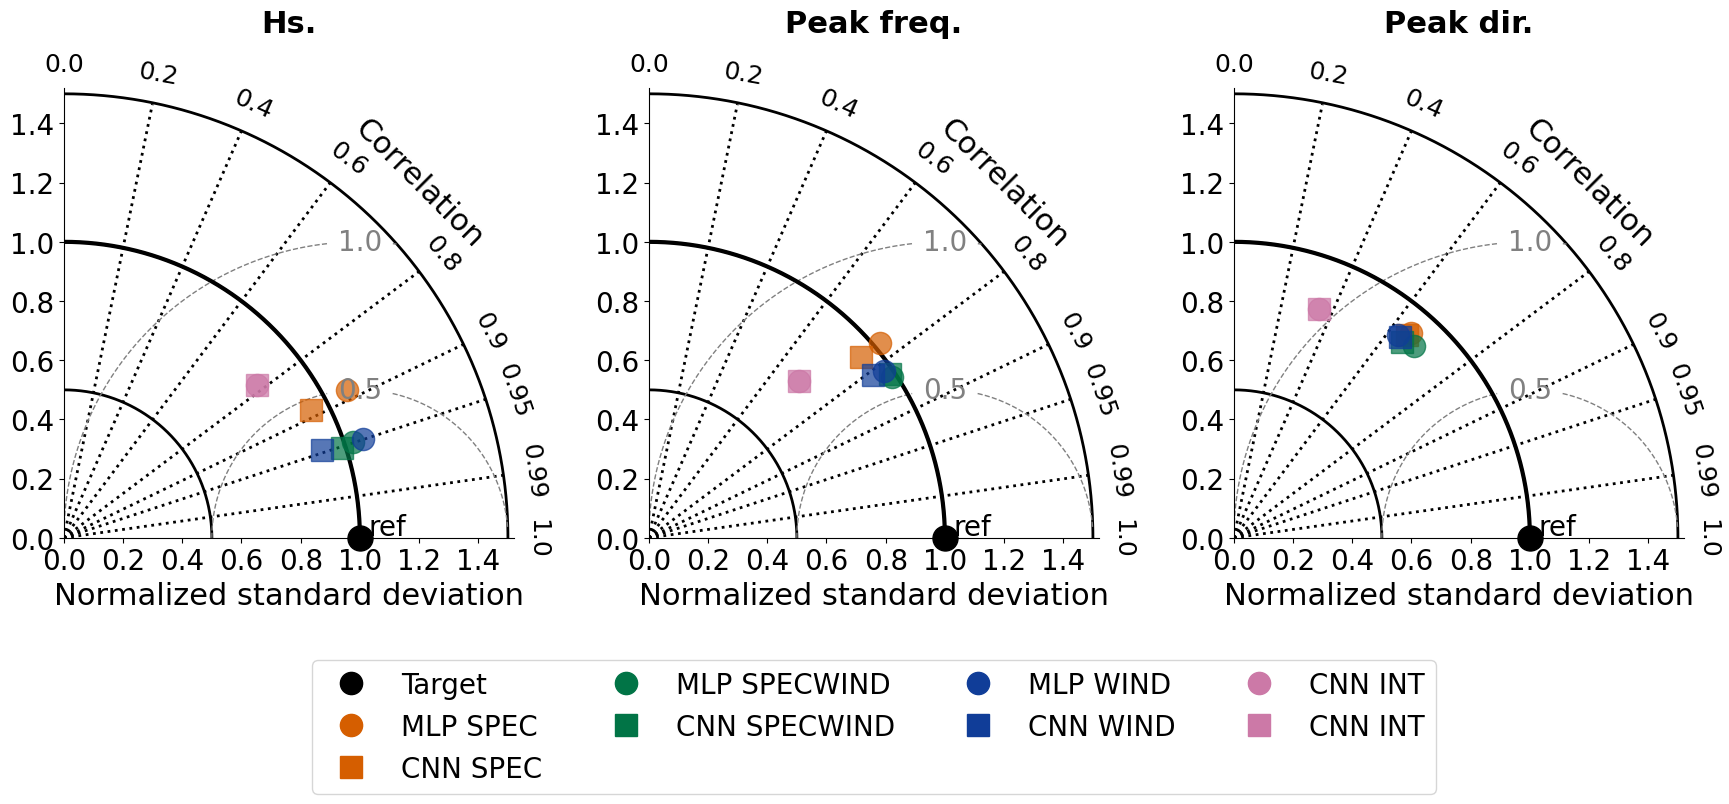

In [26]:
suffix = ['Hs', 'peak_freq', 'peak_dir']   

# fig, axes = plt.subplots(ncols=len(suffix), figsize=(20,8))
fig, axes = plt.subplots(ncols=len(suffix), figsize=(18,6))

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.90,
    bottom=0.15,
    wspace=0.3,   # horizontal space between subplots
    hspace=0.3    # vertical space between subplots
)

df_loc = df_combined_Vartdalsfjorden

for i in range(len(suffix)):

    taylor_diagram(
        df_loc,
        var_ref=[f'Target {suffix[i]}'],
        var_comp=[
                names_Vartdalsfjorden[1] + suffix[i],
                names_Vartdalsfjorden[2] + suffix[i],
                names_Vartdalsfjorden[3] + suffix[i], 
                names_Vartdalsfjorden[4] + suffix[i], 
                names_Vartdalsfjorden[5] + suffix[i], 
                names_Vartdalsfjorden[6] + suffix[i],
                names_Vartdalsfjorden[7] + suffix[i],
                names_Vartdalsfjorden[8] + suffix[i],
                # names_Sulafjorden[9] + suffix[i],
                # names_Sulafjorden[10] + suffix[i],

        ],
        norm_std=True,
        colors = [
            "#D55E00", "#D55E00",   # purple
            "#017446", "#017446",   # teal
            "#103D98", "#103D98",   # deep blue
            "#CC79A7", "#CC79A7",    # slate blue
            "#F6F605", "#F6F605",
            # "#CC79A7", "#CC79A7",    # slate blue
            
        ],
        ax = axes[i],
        filter = False,
        y_anchor=-0.6,
        marker_size=16,
        facecolor=None
        # output_file='Sulafjorden_model_performance_(2017_2023)_1hr_time_shift_no_filter_peak_dir_deg.pdf'
    )


plt.tight_layout(pad=2)
# plt.savefig('Td_Vartdalsfjorden_int_params_1hr_timeshift_combined.pdf', bbox_inches="tight", dpi=300)

Option 2


/tmp/ipykernel_3169469/3189851927.py:92: RuntimeWarning: invalid value encountered in sqrt
  ysc[r,a]=np.sqrt(radius1[r]**2-(xbc[a]-std[0])**2)
/tmp/ipykernel_3169469/3189851927.py:91: RuntimeWarning: invalid value encountered in sqrt
  ybc[r,a]=np.sqrt(radius[r]**2-xbc[a]**2)


std: [1.         1.05162466 0.98569453 1.00622768 1.0002413  1.0273875
 0.97871802]
correlation  [1.         0.84442005 0.85775892 0.90804453 0.91350001 0.91118972
 0.90853638]
removed indices:  []
var comp:  ['MLP SPEC mean_freq', 'CNN SPEC mean_freq', 'MLP SPECWIND mean_freq', 'CNN SPECWIND mean_freq', 'MLP WIND mean_freq', 'CNN WIND mean_freq'] 6
Centered RMSE (Taylor): [0.57435923 0.5297331  0.43022676 0.4159829  0.42805984 0.42365919]


/tmp/ipykernel_3169469/3189851927.py:176: RuntimeWarning: invalid value encountered in sqrt
  ybc_r=np.sqrt(std[0]**2-xbc**2)


Option 2
std: [1.         0.89423948 0.85166781 0.883942   0.86851394 0.88035123
 0.89003021]
correlation  [1.         0.67274489 0.6770277  0.72068623 0.70352691 0.73417185
 0.72981202]
removed indices:  []
var comp:  ['MLP SPEC mean_dir', 'CNN SPEC mean_dir', 'MLP SPECWIND mean_dir', 'CNN SPECWIND mean_dir', 'MLP WIND mean_dir', 'CNN WIND mean_dir'] 6
Centered RMSE (Taylor): [0.7723174  0.75639451 0.71222454 0.72956879 0.69452149 0.70217112]


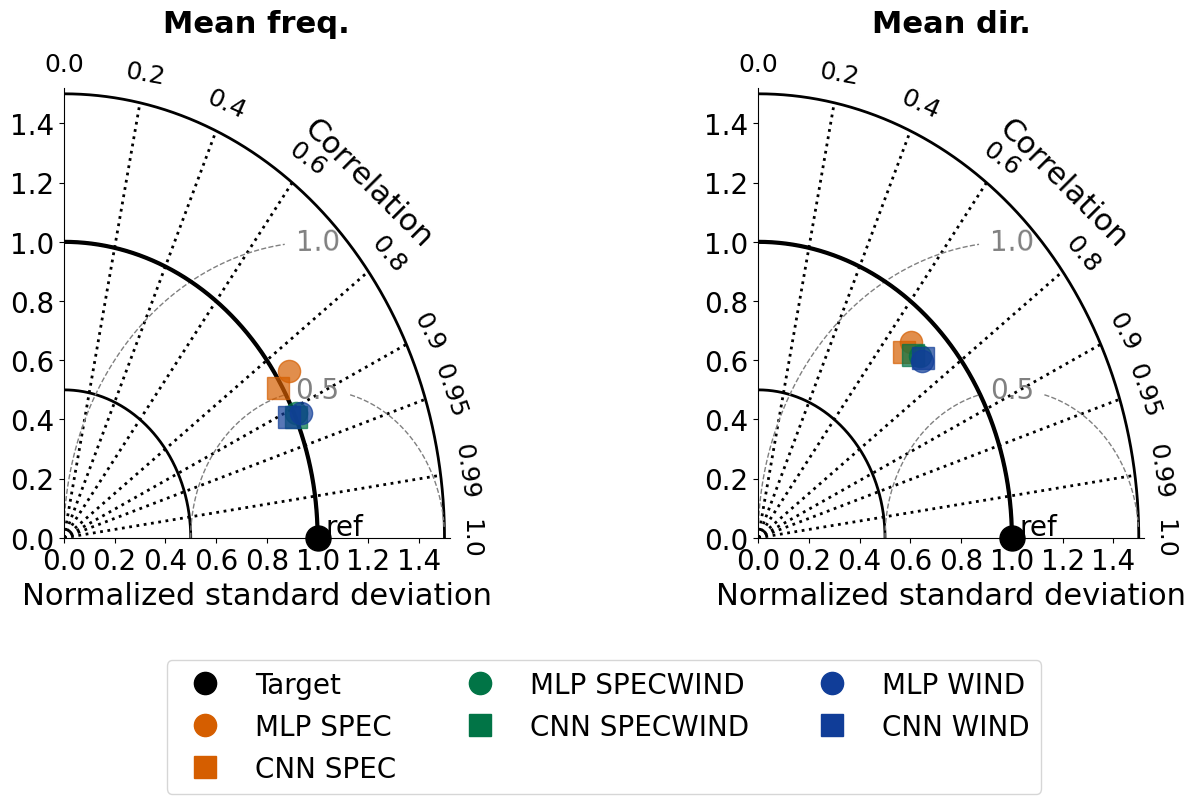

In [64]:
suffix = ['mean_freq', 'mean_dir']   

fig, axes = plt.subplots(ncols=len(suffix), figsize=(12,6))

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.90,
    bottom=0.15,
    wspace=0.8,   # horizontal space between subplots
    hspace=0.3    # vertical space between subplots
)

df_loc = df_combined_Vartdalsfjorden


for i in range(len(suffix)):
    taylor_diagram(
        df_loc,
        var_ref=[f'Target {suffix[i]}'],
        var_comp=[
                names_Vartdalsfjorden[1] + suffix[i],
                names_Vartdalsfjorden[2] + suffix[i],
                names_Vartdalsfjorden[3] + suffix[i], 
                names_Vartdalsfjorden[4] + suffix[i], 
                names_Vartdalsfjorden[5] + suffix[i], 
                names_Vartdalsfjorden[6] + suffix[i],

        ],
        norm_std=True,
        colors = [
            "#D55E00", "#D55E00",   # purple
            "#017446", "#017446",   # teal
            "#103D98", "#103D98",   # deep blue
            "#CC79A7", "#CC79A7",    # slate blue
            "#F6F605", "#F6F605",
            # "#CC79A7", "#CC79A7"    # slate blue
        ],
        ax = axes[i],
        filter = False,
        y_anchor=-0.6,
        x_anchor=-0.4,
        marker_size=16,
        facecolor=None,
        ncols=3
        # output_file='Vattøyskjæret_model_performance_based_on_hyperparameters_(2017_2023)_no_time_shift_mean.pdf'
    )


# plt.tight_layout(pad=2)
# plt.savefig('Td_Vartdalsfjorden_mean_params_1hr_timeshift_combined.pdf', bbox_inches="tight", dpi=300)